In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import f_classif

In [2]:
df=pd.read_csv("ai_student_impact_dataset (1).csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=50000, step=1)
All columns are
0 Student_ID
1 Major_Category
2 Year_of_Study
3 Pre_Semester_GPA
4 Weekly_GenAI_Hours
5 Primary_Use_Case
6 Prompt_Engineering_Skill
7 Tool_Diversity
8 Paid_Subscription
9 Traditional_Study_Hours
10 Perceived_AI_Dependency
11 Institutional_Policy
12 Anxiety_Level_During_Exams
13 Post_Semester_GPA
14 Skill_Retention_Score
15 Burnout_Risk_Level


In [3]:
df.sample(n=10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
31900,131901,Business,Senior,3.567,0.99,Debugging/Troubleshooting,Intermediate,2,True,9.47,2,Strict_Ban,3,3.525,78.84,Low
35254,135255,STEM,Freshman,3.577,14.91,Debugging/Troubleshooting,Intermediate,5,True,11.10,6,Strict_Ban,7,3.773,66.36,Medium
45173,145174,Arts,Senior,3.772,35.46,Direct_Answer_Generation,Intermediate,3,False,9.61,8,Allowed_With_Citation,5,2.954,61.72,High
15257,115258,STEM,Freshman,3.912,2.38,Ideation,Beginner,3,True,15.15,1,Actively_Encouraged,2,4.000,61.43,Low
41190,141191,STEM,Graduate,2.259,5.43,Ideation,Intermediate,4,False,11.09,4,Actively_Encouraged,5,2.579,77.24,Low
42310,142311,Humanities,Freshman,2.619,0.50,Summarizing_Reading,Beginner,1,False,9.93,2,Allowed_With_Citation,6,2.517,86.85,Low
27570,127571,Business,Freshman,2.831,5.62,Copywriting/Drafting,Beginner,2,True,9.45,4,Allowed_With_Citation,4,2.940,62.08,Low
37631,137632,Business,Freshman,2.937,2.98,Direct_Answer_Generation,Advanced,3,False,10.45,2,Actively_Encouraged,5,2.901,56.43,Medium
24745,124746,Business,Junior,3.141,9.98,Ideation,Intermediate,1,False,14.46,2,Allowed_With_Citation,3,3.396,98.35,Medium
28510,128511,Humanities,Freshman,2.557,0.19,Debugging/Troubleshooting,Beginner,3,False,9.57,1,Allowed_With_Citation,3,2.423,71.09,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [5]:
# Removing null values
df = df.dropna()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

<Axes: >

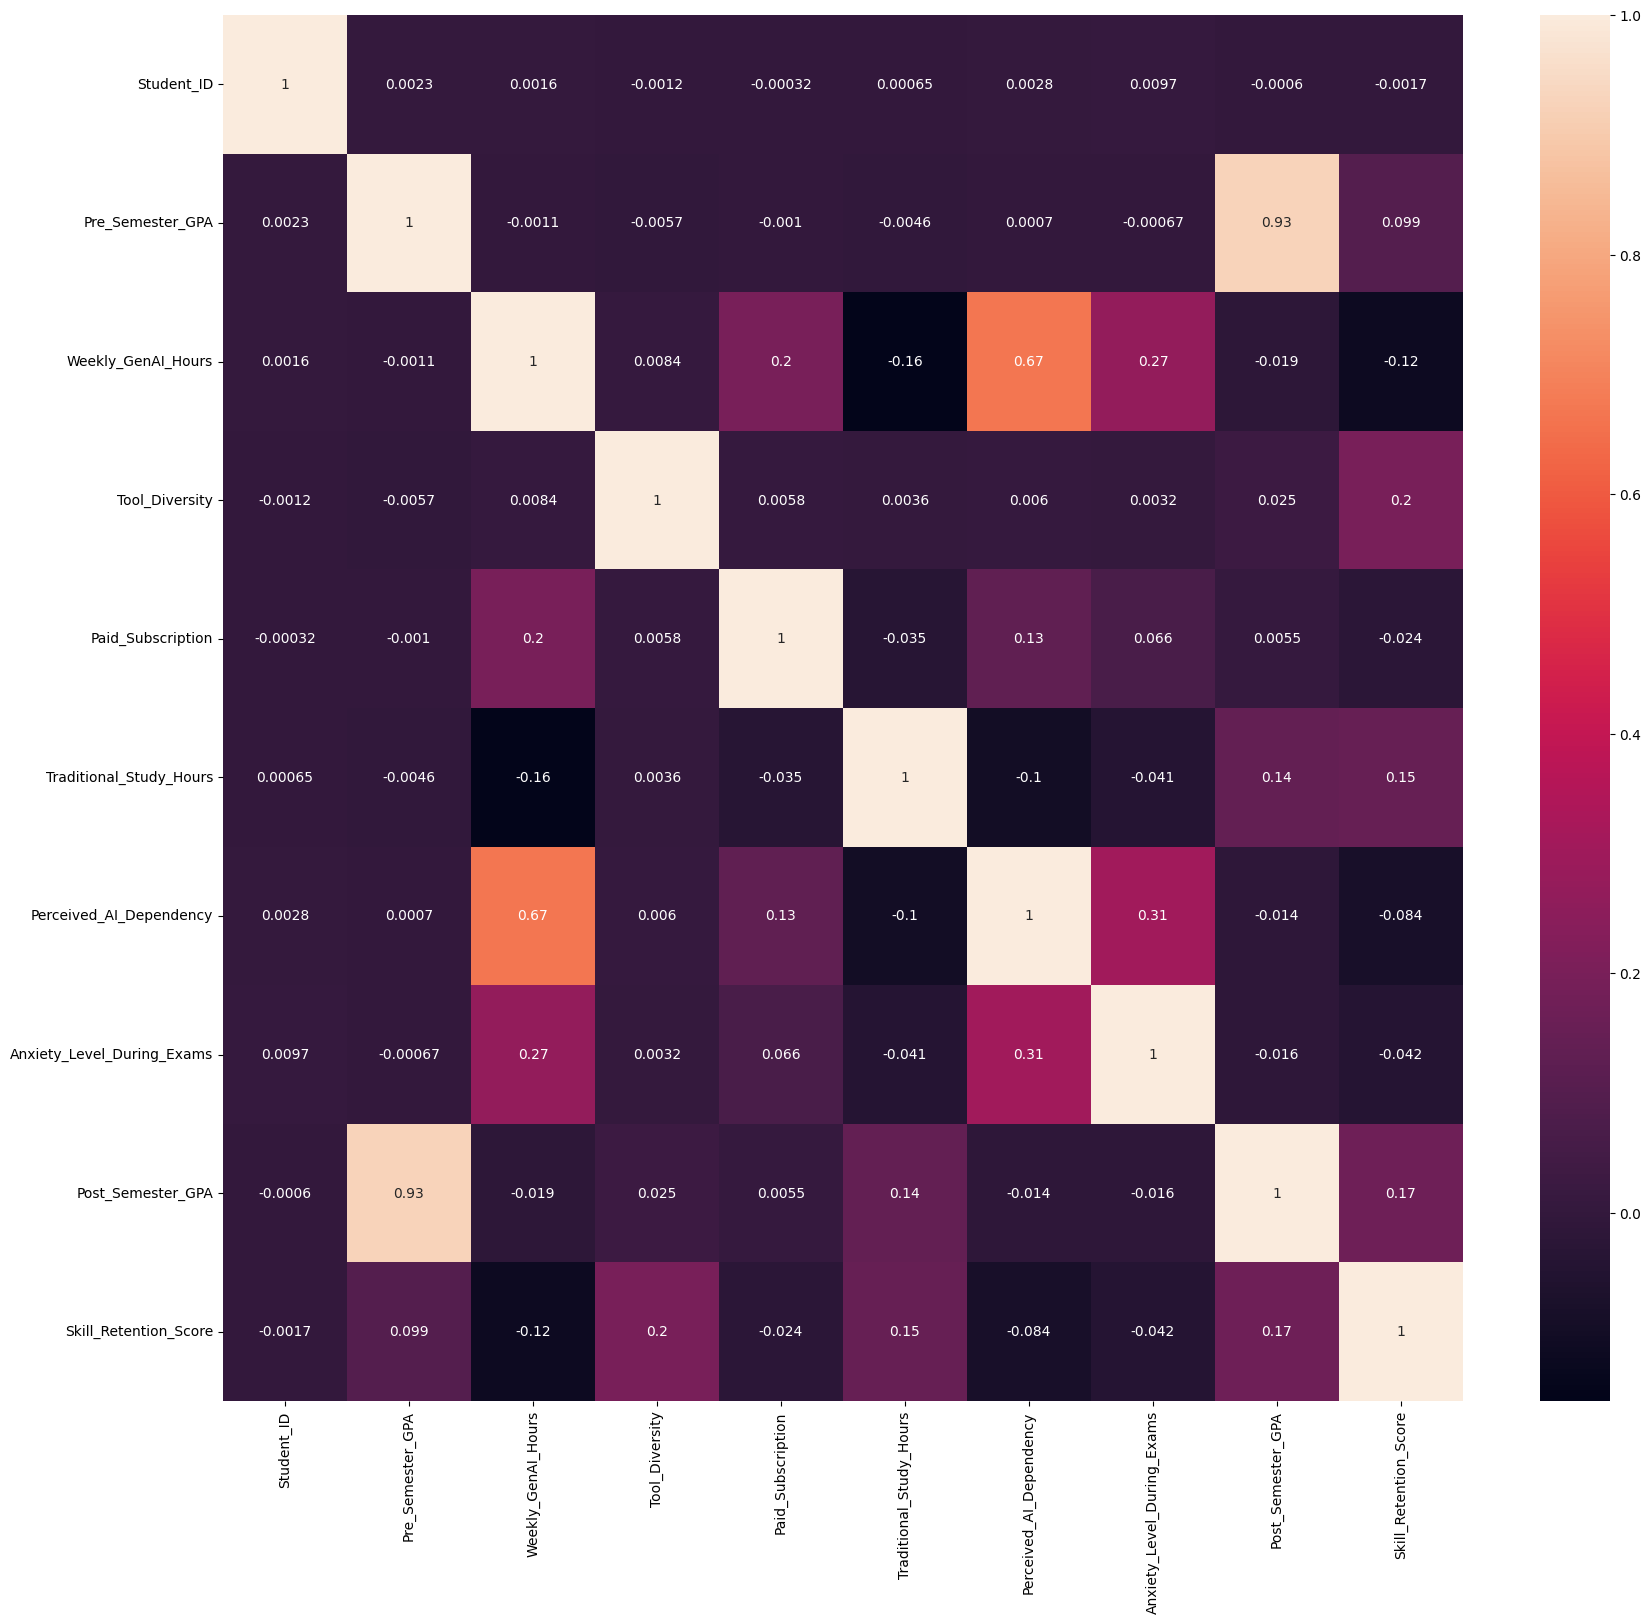

In [6]:
plt.figure(figsize=(20,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [15]:
print('''The Heatmap may not give the best relationship between the features.
As our feature are numerical and the target is categorial
So the best test will be ANOVA F-Test''')

The Heatmap may not give the best relationship between the features.
As our feature are numerical and the target is categorial
So the best test will be ANOVA F-Test


In [8]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [9]:
df.select_dtypes(include='number').columns

Index(['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score'],
      dtype='object')

In [10]:
# Isolating input and target
X = df[df.select_dtypes(include='number').columns]
y = df["Burnout_Risk_Level"]

In [11]:
fscores, pvalues = f_classif(X, y)

anovadf = pd.DataFrame({"Feature": X.columns,"F-Score": fscores,"p-value": pvalues})

anovadf = anovadf.sort_values(by="F-Score",ascending=False)

print(anovadf.round(4))

                      Feature    F-Score  p-value
2          Weekly_GenAI_Hours  8067.4026   0.0000
5     Perceived_AI_Dependency  4279.8586   0.0000
6  Anxiety_Level_During_Exams   774.6620   0.0000
4     Traditional_Study_Hours   486.3186   0.0000
1            Pre_Semester_GPA   234.3675   0.0000
7           Post_Semester_GPA   231.4443   0.0000
8       Skill_Retention_Score   113.7704   0.0000
3              Tool_Diversity     0.8452   0.4295
0                  Student_ID     0.4330   0.6485


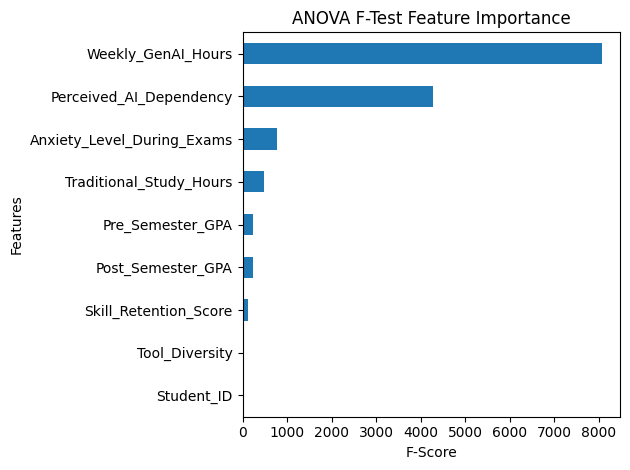

In [12]:
anovadf.sort_values("F-Score").plot(x="Feature",y="F-Score",kind="barh",legend=False)

plt.title("ANOVA F-Test Feature Importance")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [14]:
print('''The test tells us that Weekly_GenAI_Hours column has the highest impact on the switch
Tool Diversity have the least impact so we can safely drop it
''')

The test tells us that Weekly_GenAI_Hours column has the highest impact on the switch
Tool Diversity have the least impact so we can safely drop it

